In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import string

In [2]:
# Step 1: Load data from the text file
file_path = r"F:\geodata\river_runoff_obs\note\note_2025-12-09_00-13-59_mon.txt"  # Replace with the path to
data = []

with open(file_path, "r") as file:
    for line in file:
        if line.startswith("Name:"):
            parts = line.split(",")
            if parts[3] ==' ig':
                continue
            name = parts[0].split("_")[1]  # Extract station name (e.g., '1_hsg')
            gcm = parts[0].split("_")[3]   # Extract GCM name (e.g., 'BCC-CSM2-MR')
            scenario = parts[1].split(":")[1].strip().upper()  # Extract scenario
            nse = float(parts[5].split(":")[1].strip())  # Extract NSE
            kge = float(parts[6].split(":")[1].strip())  # Extract KGE
            pbias = float(parts[7].split(":")[1].strip())  # Extract Pbias
            data.append((name, gcm, scenario, nse, kge, pbias))

# Step 2: Convert to DataFrame
columns = ["Station", "GCM", "Scenario", "NSE", "KGE", "Pbias"]
evaluation_df = pd.DataFrame(data, columns=columns)


# Step 1: Load data from the text file
file_path = r"F:\geodata\river_runoff_obs\note\note_2025-04-30_13-00-02_mon.txt"  # Replace with the path to
data = []

with open(file_path, "r") as file:
    for line in file:
        if line.startswith("Name:"):
            parts = line.split(",")
            name = parts[0].split("_")[1]  # Extract station name (e.g., '1_hsg')
            gcm = parts[0].split("_")[3]   # Extract GCM name (e.g., 'BCC-CSM2-MR')
            scenario = parts[1].split(":")[1].strip().upper()  # Extract scenario
            nse = float(parts[5].split(":")[1].strip())  # Extract NSE
            kge = float(parts[6].split(":")[1].strip())  # Extract KGE
            pbias = float(parts[7].split(":")[1].strip())  # Extract Pbias
            data.append((name, gcm, scenario, nse, kge, pbias))

# Step 2: Convert to DataFrame
columns = ["Station", "GCM", "Scenario", "NSE", "KGE", "Pbias"]
evaluation_df_unchanged = pd.DataFrame(data, columns=columns)

In [3]:
evaluation_df_unchanged

,Station,GCM,Scenario,NSE,KGE,Pbias
0,hsg,FGOALS-g3,SSP126,0.608518,0.517018,13.749999
1,hsg,FGOALS-g3,SSP245,0.652314,0.560437,10.220562
2,hsg,FGOALS-g3,SSP370,0.579680,0.495513,15.205240
3,hsg,FGOALS-g3,SSP585,0.659151,0.568054,9.641485
4,dsk,FGOALS-g3,SSP126,0.501051,0.645025,-3.313473
...,...,...,...,...,...,...
191,wlwt,INM-CM4-8,SSP585,0.782448,0.866812,-6.334091
192,tgzlk,INM-CM4-8,SSP126,0.862693,0.857737,0.543881
193,tgzlk,INM-CM4-8,SSP245,0.847334,0.827226,6.618702
194,tgzlk,INM-CM4-8,SSP370,0.832437,0.809857,9.239958


In [9]:
evaluation_df_merged = evaluation_df.merge(evaluation_df_unchanged, left_index=True, right_index=True)
evaluation_df_merged

,Station_x,GCM_x,Scenario_x,NSE_x,KGE_x,Pbias_x,Station_y,GCM_y,Scenario_y,NSE_y,KGE_y,Pbias_y
0,hsg,FGOALS-g3,SSP126,0.633705,0.546388,17.363944,hsg,FGOALS-g3,SSP126,0.608518,0.517018,13.749999
1,hsg,FGOALS-g3,SSP245,0.671342,0.595458,12.219208,hsg,FGOALS-g3,SSP245,0.652314,0.560437,10.220562
2,hsg,FGOALS-g3,SSP370,0.554206,0.534066,13.066933,hsg,FGOALS-g3,SSP370,0.579680,0.495513,15.205240
3,hsg,FGOALS-g3,SSP585,0.720353,0.611819,9.156933,hsg,FGOALS-g3,SSP585,0.659151,0.568054,9.641485
4,dsk,FGOALS-g3,SSP126,0.687831,0.732815,-2.781868,dsk,FGOALS-g3,SSP126,0.501051,0.645025,-3.313473
...,...,...,...,...,...,...,...,...,...,...,...,...
191,wlwt,INM-CM4-8,SSP585,0.766557,0.861402,-3.987339,wlwt,INM-CM4-8,SSP585,0.782448,0.866812,-6.334091
192,tgzlk,INM-CM4-8,SSP126,0.739943,0.845150,-3.928802,tgzlk,INM-CM4-8,SSP126,0.862693,0.857737,0.543881
193,tgzlk,INM-CM4-8,SSP245,0.810310,0.860561,5.462715,tgzlk,INM-CM4-8,SSP245,0.847334,0.827226,6.618702
194,tgzlk,INM-CM4-8,SSP370,0.779955,0.696119,12.078259,tgzlk,INM-CM4-8,SSP370,0.832437,0.809857,9.239958


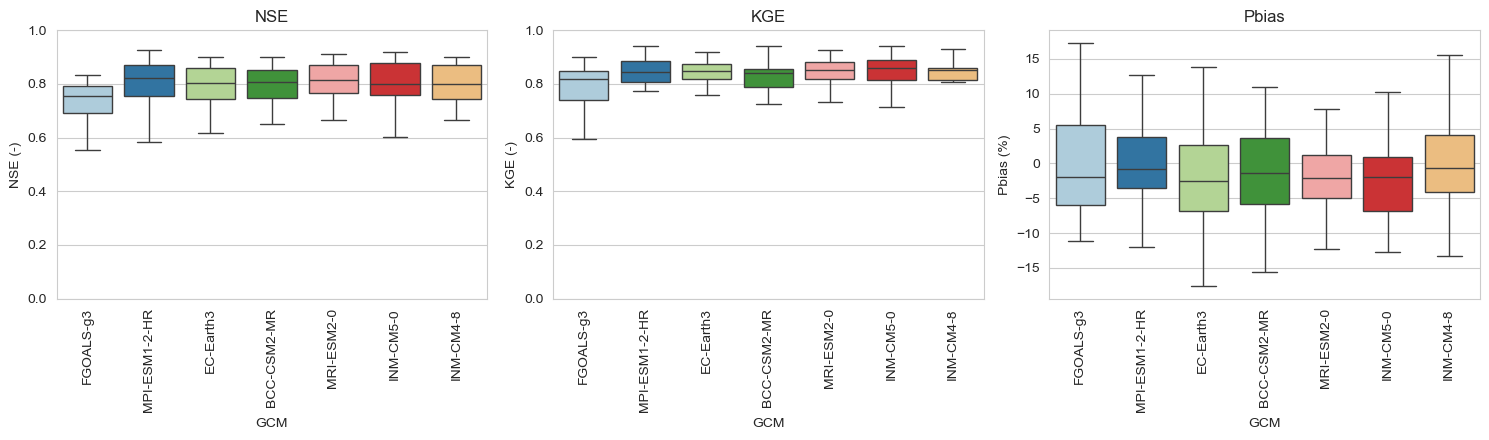

In [4]:
# Step 3: Create a single figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))  # 1 row, 3 columns

# Subplot 1: NSE
sns.boxplot(data=evaluation_df, x="GCM", y="NSE", hue="GCM", showfliers=False, palette="Paired", dodge=False, ax=axes[0])
axes[0].set_title("NSE")
axes[0].set_xlabel("GCM")
axes[0].set_ylabel("NSE (-)")
axes[0].set_ylim(bottom=0, top=1)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=90)

# Subplot 2: KGE
sns.boxplot(data=evaluation_df, x="GCM", y="KGE", hue="GCM", showfliers=False, palette="Paired", dodge=False, ax=axes[1])
axes[1].set_title("KGE")
axes[1].set_xlabel("GCM")
axes[1].set_ylabel("KGE (-)")
axes[1].set_ylim(bottom=0, top=1)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=90)

# Subplot 3: Pbias
sns.boxplot(data=evaluation_df, x="GCM", y="Pbias", hue="GCM", showfliers=False, palette="Paired", dodge=False, ax=axes[2])
axes[2].set_title("Pbias")
axes[2].set_xlabel("GCM")
axes[2].set_ylabel("Pbias (%)")
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=90)

# Adjust layout and show the figure
# Create a figure with a white background
# plt.figure(facecolor='white')
plt.tight_layout()
plt.show()


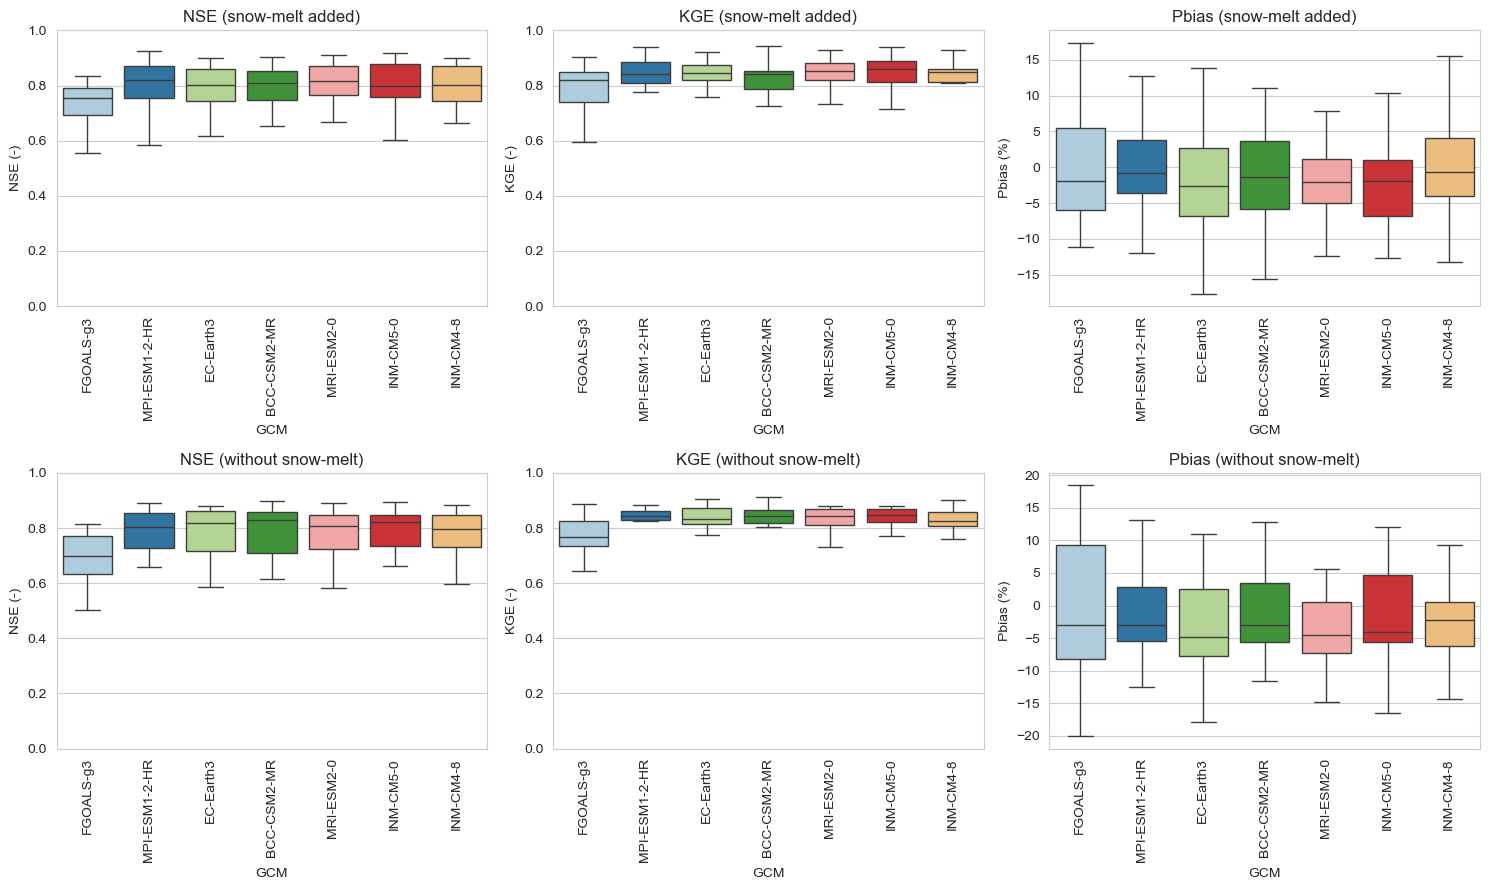

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a single figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(15, 9))  # 6 subplots total
axes = axes.ravel()  # flatten (easier indexing)

# Common plot settings
plot_params = dict(showfliers=False, palette="Paired", dodge=False)

# ----------- FIRST ROW: evaluation_df -----------
sns.boxplot(data=evaluation_df, x="GCM", y="NSE", hue="GCM", ax=axes[0], **plot_params)
axes[0].set(title="NSE (snow-melt added)", xlabel="GCM", ylabel="NSE (-)", ylim=(0, 1))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=90)

sns.boxplot(data=evaluation_df, x="GCM", y="KGE", hue="GCM", ax=axes[1], **plot_params)
axes[1].set(title="KGE (snow-melt added)", xlabel="GCM", ylabel="KGE (-)", ylim=(0, 1))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=90)

sns.boxplot(data=evaluation_df, x="GCM", y="Pbias", hue="GCM", ax=axes[2], **plot_params)
axes[2].set(title="Pbias (snow-melt added)", xlabel="GCM", ylabel="Pbias (%)")
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=90)

# ----------- SECOND ROW: evaluation_df_unchanged -----------
sns.boxplot(data=evaluation_df_unchanged, x="GCM", y="NSE", hue="GCM", ax=axes[3], **plot_params)
axes[3].set(title="NSE (without snow-melt)", xlabel="GCM", ylabel="NSE (-)", ylim=(0, 1))
plt.setp(axes[3].xaxis.get_majorticklabels(), rotation=90)

sns.boxplot(data=evaluation_df_unchanged, x="GCM", y="KGE", hue="GCM", ax=axes[4], **plot_params)
axes[4].set(title="KGE (without snow-melt)", xlabel="GCM", ylabel="KGE (-)", ylim=(0, 1))
plt.setp(axes[4].xaxis.get_majorticklabels(), rotation=90)

sns.boxplot(data=evaluation_df_unchanged, x="GCM", y="Pbias", hue="GCM", ax=axes[5], **plot_params)
axes[5].set(title="Pbias (without snow-melt)", xlabel="GCM", ylabel="Pbias (%)")
plt.setp(axes[5].xaxis.get_majorticklabels(), rotation=90)

# Adjust layout and show
plt.tight_layout()
plt.show()


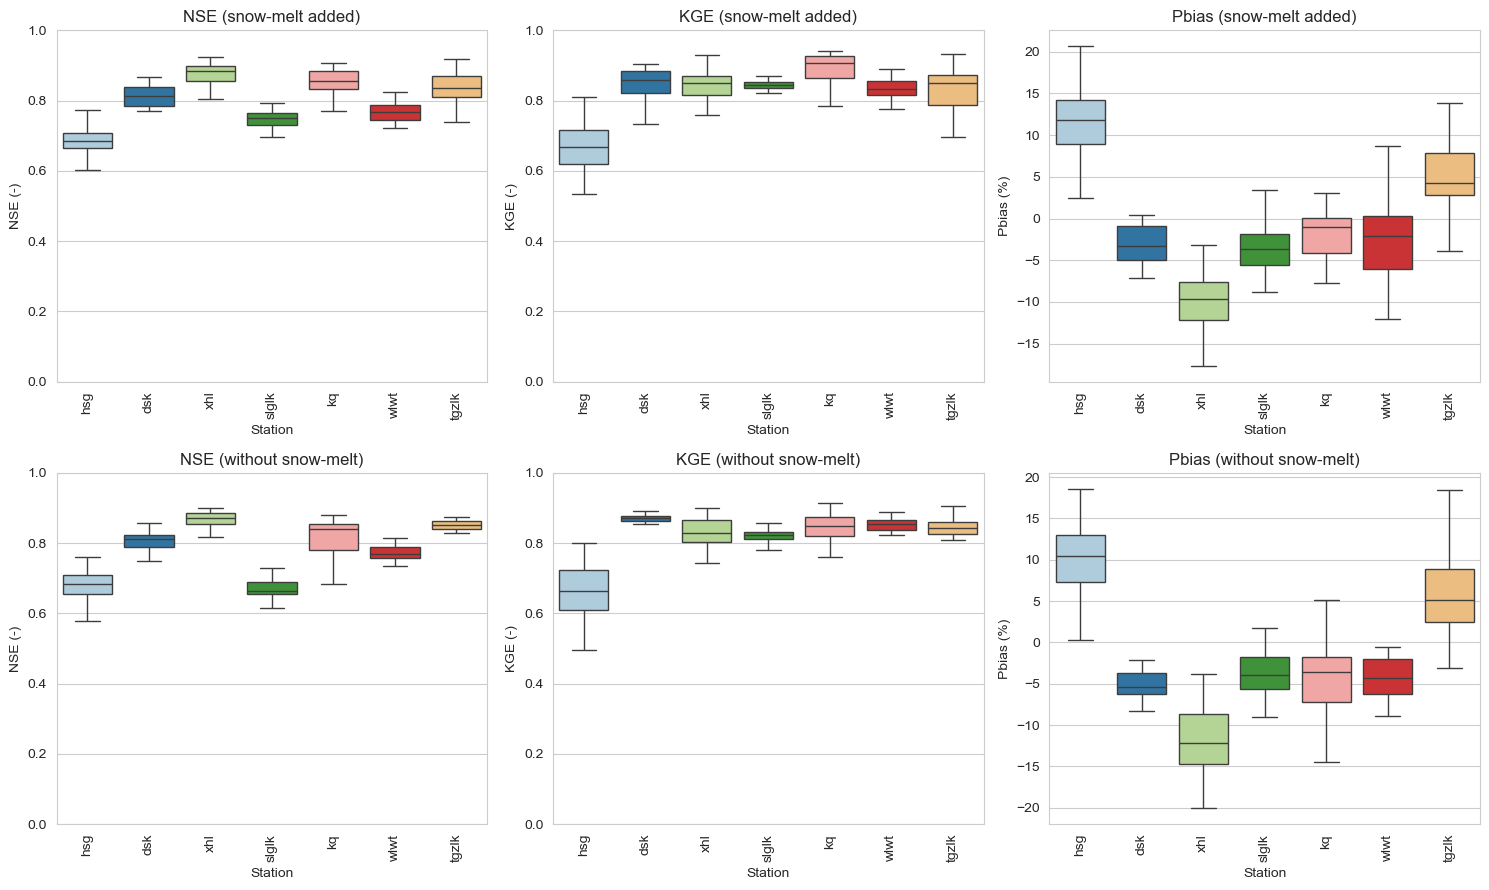

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a single figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(15, 9))  # 6 subplots total
axes = axes.ravel()  # flatten (easier indexing)

# Common plot settings
plot_params = dict(showfliers=False, palette="Paired", dodge=False)

# ----------- FIRST ROW: evaluation_df -----------
sns.boxplot(data=evaluation_df, x="Station", y="NSE", hue="Station", ax=axes[0], **plot_params)
axes[0].set(title="NSE (snow-melt added)", xlabel="Station", ylabel="NSE (-)", ylim=(0, 1))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=90)

sns.boxplot(data=evaluation_df, x="Station", y="KGE", hue="Station", ax=axes[1], **plot_params)
axes[1].set(title="KGE (snow-melt added)", xlabel="Station", ylabel="KGE (-)", ylim=(0, 1))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=90)

sns.boxplot(data=evaluation_df, x="Station", y="Pbias", hue="Station", ax=axes[2], **plot_params)
axes[2].set(title="Pbias (snow-melt added)", xlabel="Station", ylabel="Pbias (%)")
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=90)

# ----------- SECOND ROW: evaluation_df_unchanged -----------
sns.boxplot(data=evaluation_df_unchanged, x="Station", y="NSE", hue="Station", ax=axes[3], **plot_params)
axes[3].set(title="NSE (without snow-melt)", xlabel="Station", ylabel="NSE (-)", ylim=(0, 1))
plt.setp(axes[3].xaxis.get_majorticklabels(), rotation=90)

sns.boxplot(data=evaluation_df_unchanged, x="Station", y="KGE", hue="Station", ax=axes[4], **plot_params)
axes[4].set(title="KGE (without snow-melt)", xlabel="Station", ylabel="KGE (-)", ylim=(0, 1))
plt.setp(axes[4].xaxis.get_majorticklabels(), rotation=90)

sns.boxplot(data=evaluation_df_unchanged, x="Station", y="Pbias", hue="Station", ax=axes[5], **plot_params)
axes[5].set(title="Pbias (without snow-melt)", xlabel="Station", ylabel="Pbias (%)")
plt.setp(axes[5].xaxis.get_majorticklabels(), rotation=90)

# Adjust layout and show
plt.tight_layout()
plt.show()


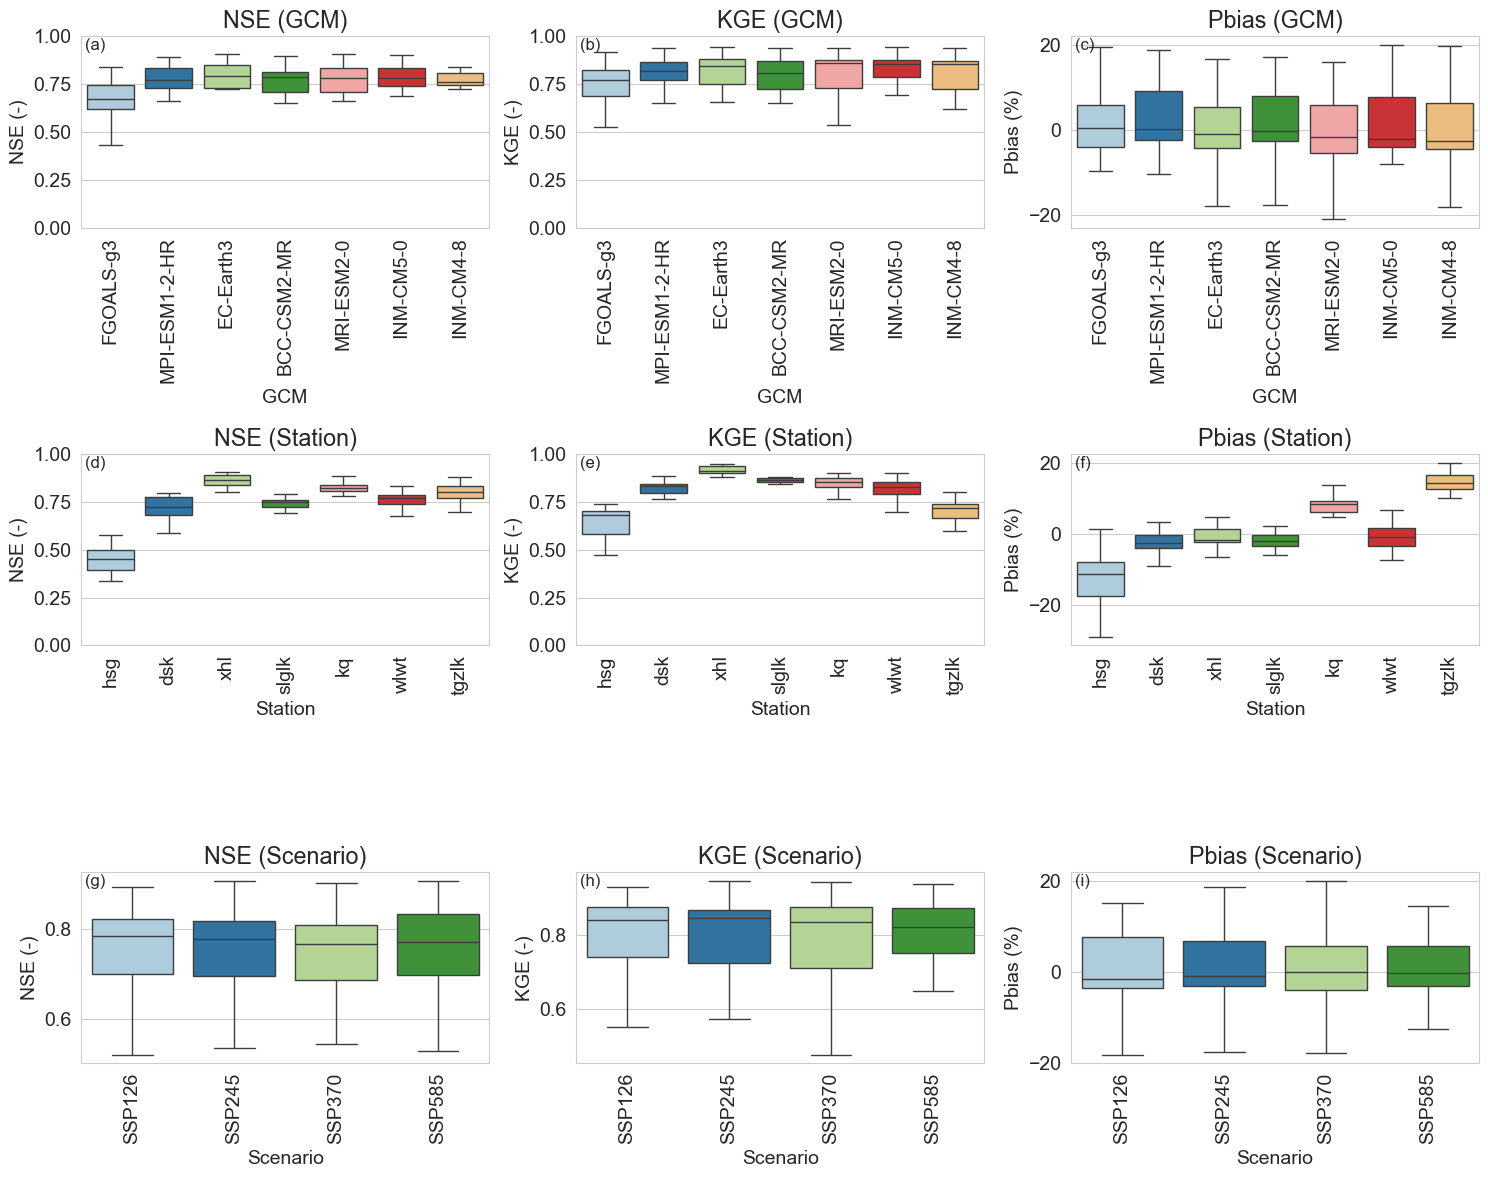

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 14})  # Change 14 to your desired font size

# Create a single figure with 3 rows and 3 columns
fig, axes = plt.subplots(3, 3, figsize=(15, 12))  # 3 rows, 3 columns

# Row 1: GCM
sns.boxplot(data=evaluation_df, x="GCM", y="NSE", hue="GCM", showfliers=False, palette="Paired", dodge=False, ax=axes[0, 0])
axes[0, 0].set_title("NSE (GCM)")
axes[0, 0].set_xlabel("GCM")
axes[0, 0].set_ylabel("NSE (-)")
axes[0, 0].set_ylim(0, 1)
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=90)

sns.boxplot(data=evaluation_df, x="GCM", y="KGE", hue="GCM", showfliers=False, palette="Paired", dodge=False, ax=axes[0, 1])
axes[0, 1].set_title("KGE (GCM)")
axes[0, 1].set_xlabel("GCM")
axes[0, 1].set_ylabel("KGE (-)")
axes[0, 1].set_ylim(0, 1)
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=90)

sns.boxplot(data=evaluation_df, x="GCM", y="Pbias", hue="GCM", showfliers=False, palette="Paired", dodge=False, ax=axes[0, 2])
axes[0, 2].set_title("Pbias (GCM)")
axes[0, 2].set_xlabel("GCM")
axes[0, 2].set_ylabel("Pbias (%)")
plt.setp(axes[0, 2].xaxis.get_majorticklabels(), rotation=90)

# Row 2: Station
sns.boxplot(data=evaluation_df, x="Station", y="NSE", hue="Station", showfliers=False, palette="Paired", dodge=False, ax=axes[1, 0])
axes[1, 0].set_title("NSE (Station)")
axes[1, 0].set_xlabel("Station")
axes[1, 0].set_ylabel("NSE (-)")
axes[1, 0].set_ylim(0, 1)
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=90)

sns.boxplot(data=evaluation_df, x="Station", y="KGE", hue="Station", showfliers=False, palette="Paired", dodge=False, ax=axes[1, 1])
axes[1, 1].set_title("KGE (Station)")
axes[1, 1].set_xlabel("Station")
axes[1, 1].set_ylabel("KGE (-)")
axes[1, 1].set_ylim(0, 1)
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=90)

sns.boxplot(data=evaluation_df, x="Station", y="Pbias", hue="Station", showfliers=False, palette="Paired", dodge=False, ax=axes[1, 2])
axes[1, 2].set_title("Pbias (Station)")
axes[1, 2].set_xlabel("Station")
axes[1, 2].set_ylabel("Pbias (%)")
plt.setp(axes[1, 2].xaxis.get_majorticklabels(), rotation=90)

# Row 3: Scenario
sns.boxplot(data=evaluation_df, x="Scenario", y="NSE", hue="Scenario", showfliers=False, palette="Paired", dodge=False, ax=axes[2, 0])
axes[2, 0].set_title("NSE (Scenario)")
axes[2, 0].set_xlabel("Scenario")
axes[2, 0].set_ylabel("NSE (-)")
plt.setp(axes[2, 0].xaxis.get_majorticklabels(), rotation=90)

sns.boxplot(data=evaluation_df, x="Scenario", y="KGE", hue="Scenario", showfliers=False, palette="Paired", dodge=False, ax=axes[2, 1])
axes[2, 1].set_title("KGE (Scenario)")
axes[2, 1].set_xlabel("Scenario")
axes[2, 1].set_ylabel("KGE (-)")
plt.setp(axes[2, 1].xaxis.get_majorticklabels(), rotation=90)

sns.boxplot(data=evaluation_df, x="Scenario", y="Pbias", hue="Scenario", showfliers=False, palette="Paired", dodge=False, ax=axes[2, 2])
axes[2, 2].set_title("Pbias (Scenario)")
axes[2, 2].set_xlabel("Scenario")
axes[2, 2].set_ylabel("Pbias (%)")
plt.setp(axes[2, 2].xaxis.get_majorticklabels(), rotation=90)

labels = list(string.ascii_lowercase)

axes_flat = axes.flatten()
# Add a label like (a), (b), (c)... to each subplot
for idx, ax in enumerate(axes_flat):
    ax.text(
        0.01, 0.99, f'({labels[idx]})',
        transform=ax.transAxes,
        fontsize=12,
        va='top',
        ha='left'
    )

# Adjust layout and display
plt.tight_layout()
plt.show()


In [46]:
evaluation_df

,Station,GCM,Scenario,NSE,KGE,Pbias
0,hsg,FGOALS-g3,SSP126,0.432231,0.552673,-9.304094
1,hsg,FGOALS-g3,SSP245,0.418341,0.572974,-8.609962
2,hsg,FGOALS-g3,SSP370,0.439090,0.589217,-9.523820
3,hsg,FGOALS-g3,SSP585,0.399556,0.525434,-5.580330
4,dsk,FGOALS-g3,SSP126,0.519775,0.763511,-5.991784
...,...,...,...,...,...,...
191,wlwt,INM-CM4-8,SSP585,0.747997,0.869259,-2.444631
192,tgzlk,INM-CM4-8,SSP126,0.802107,0.717284,14.505041
193,tgzlk,INM-CM4-8,SSP245,0.760693,0.706029,16.669263
194,tgzlk,INM-CM4-8,SSP370,0.758892,0.620100,19.931005


C:\Users\HP\AppData\Local\Temp\ipykernel_58580\2383772897.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=station_data, x="Scenario", y=item, showfliers=False, palette="Paired", ax=axes[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_58580\2383772897.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=station_data, x="Scenario", y=item, showfliers=False, palette="Paired", ax=axes[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_58580\2383772897.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=station_data, x="Scenario", y=i

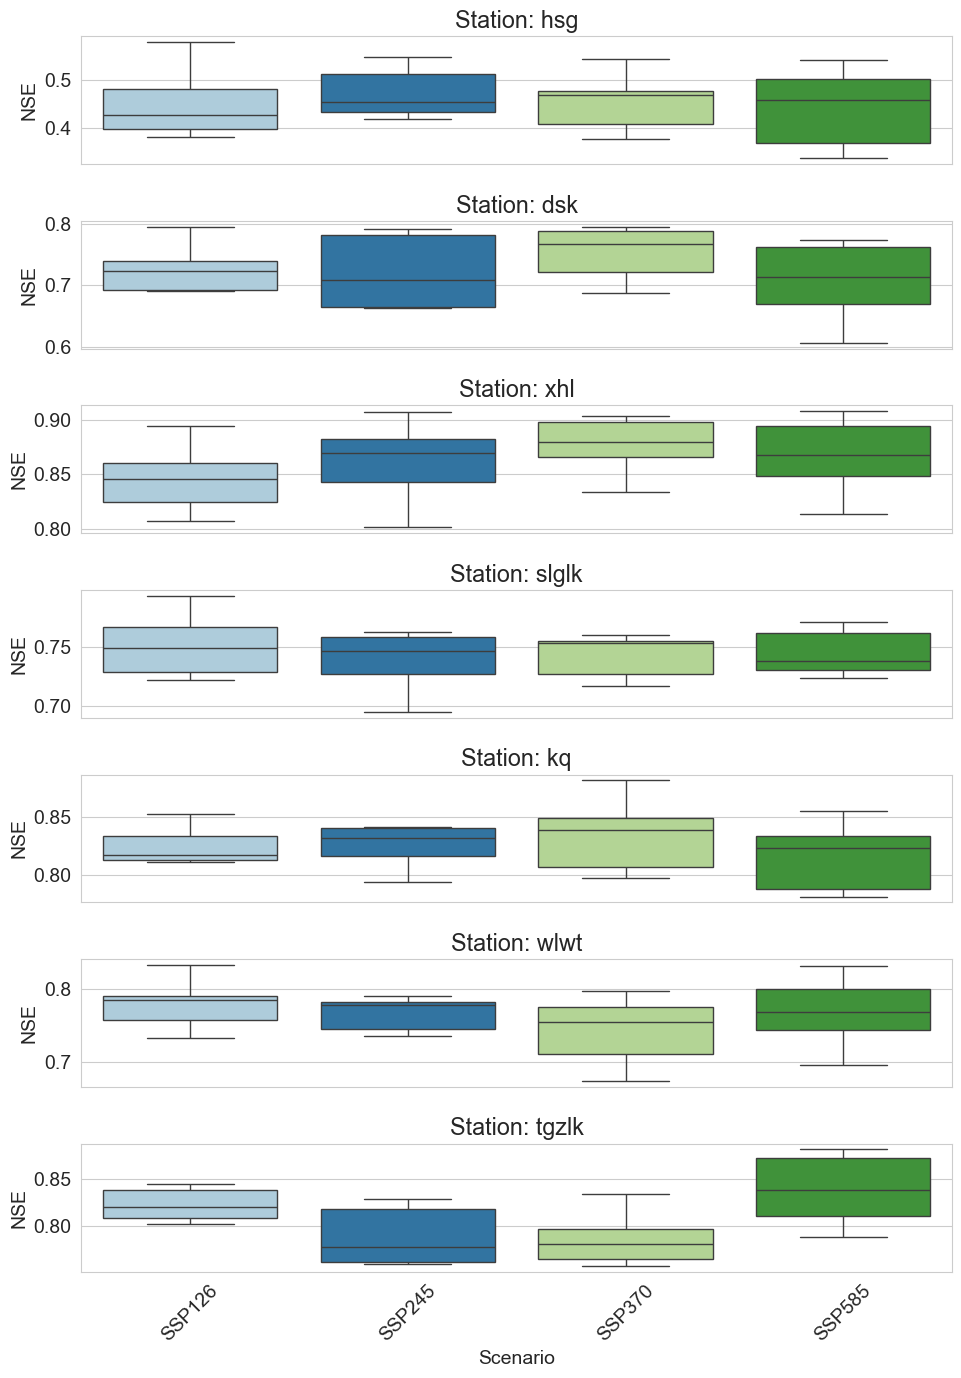

C:\Users\HP\AppData\Local\Temp\ipykernel_58580\2383772897.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=station_data, x="Scenario", y=item, showfliers=False, palette="Paired", ax=axes[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_58580\2383772897.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=station_data, x="Scenario", y=item, showfliers=False, palette="Paired", ax=axes[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_58580\2383772897.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=station_data, x="Scenario", y=i

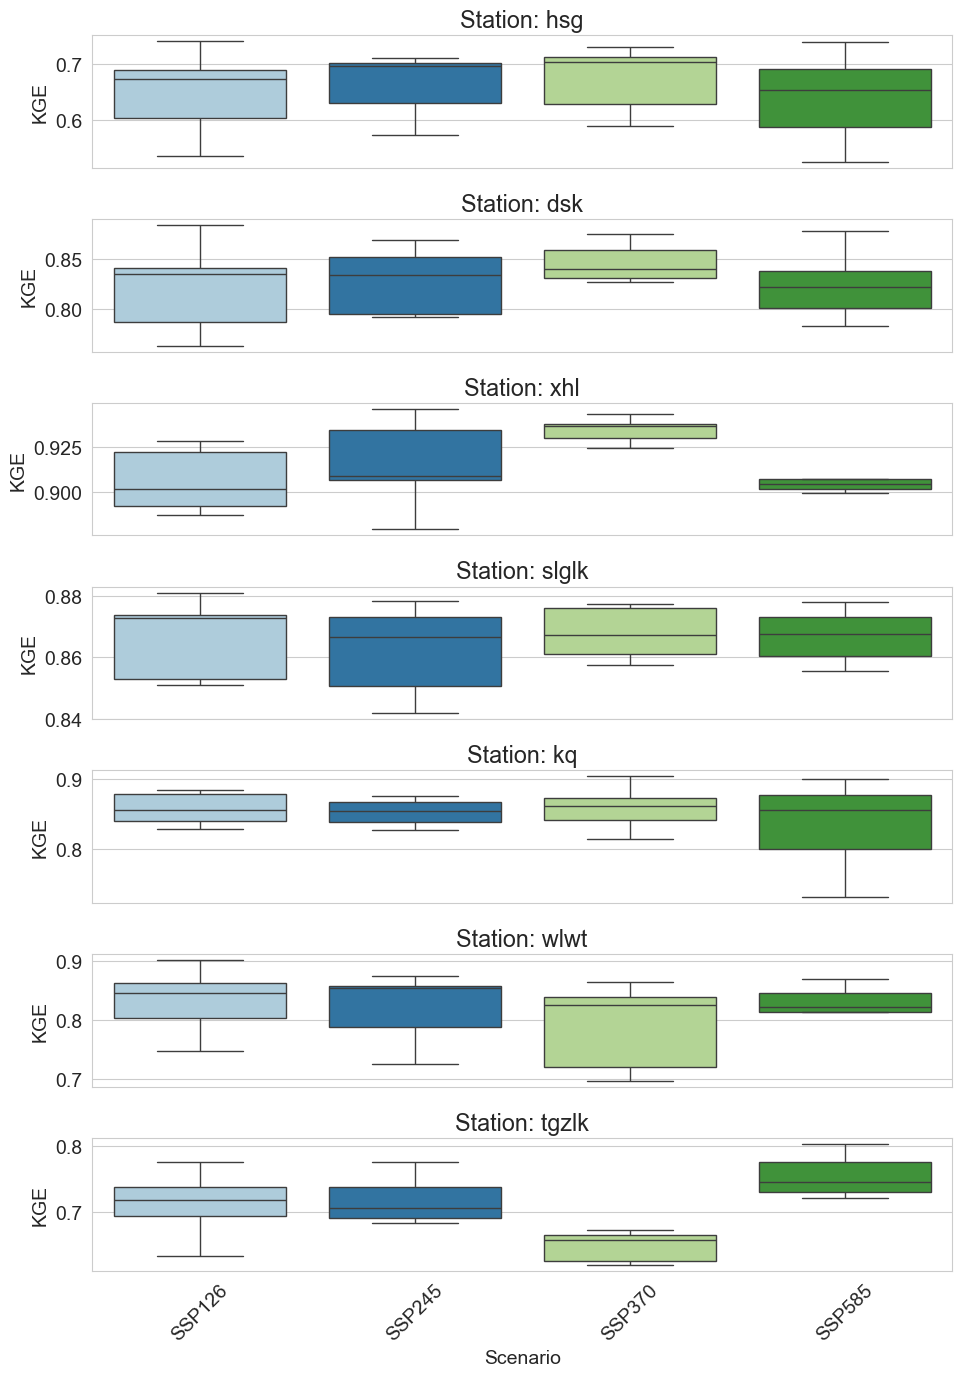

C:\Users\HP\AppData\Local\Temp\ipykernel_58580\2383772897.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=station_data, x="Scenario", y=item, showfliers=False, palette="Paired", ax=axes[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_58580\2383772897.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=station_data, x="Scenario", y=item, showfliers=False, palette="Paired", ax=axes[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_58580\2383772897.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=station_data, x="Scenario", y=i

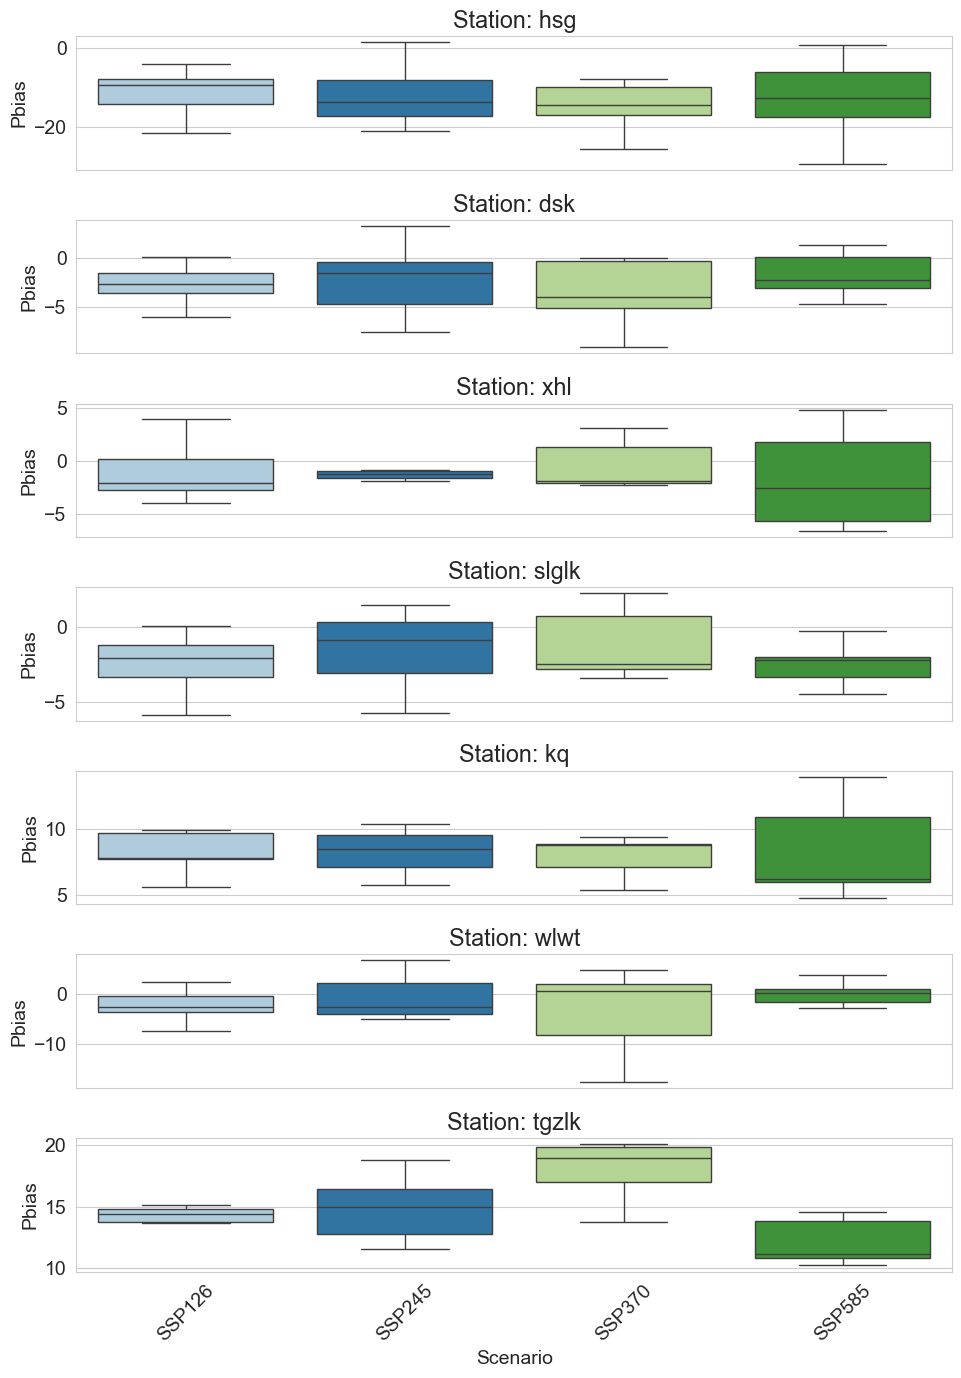

In [47]:
# Filter unique stations
stations = evaluation_df['Station'].unique()

for item in ['NSE', 'KGE', 'Pbias']:
    # Set up the figure
    fig, axes = plt.subplots(len(stations), 1, figsize=(9.84, len(stations) * 2))  # 7 rows, 1 column
    fig.subplots_adjust(hspace=0.4)  # Adjust spacing between subplots

    # Loop through each station and create a plot
    for i, station in enumerate(stations):
        station_data = evaluation_df[evaluation_df['Station'] == station]
        sns.boxplot(data=station_data, x="Scenario", y=item, showfliers=False, palette="Paired", ax=axes[i])
        axes[i].set_title(f"Station: {station}")
        axes[i].set_ylabel(item)
        plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45)  # Rotate x-axis labels

        # Remove x labels for all but the last plot
        if i < len(stations) - 1:
            axes[i].set_xlabel("")
            axes[i].set_xticklabels([])

    # Add x-axis label only to the last subplot
    axes[-1].set_xlabel("Scenario")

    # Show the figure

    plt.tight_layout()
    plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_58580\498802271.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gcm_data, x="Station", y="NSE", showfliers=False, palette="Paired", ax=axes[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_58580\498802271.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gcm_data, x="Station", y="NSE", showfliers=False, palette="Paired", ax=axes[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_58580\498802271.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gcm_data, x="Station", y="NSE", showfliers

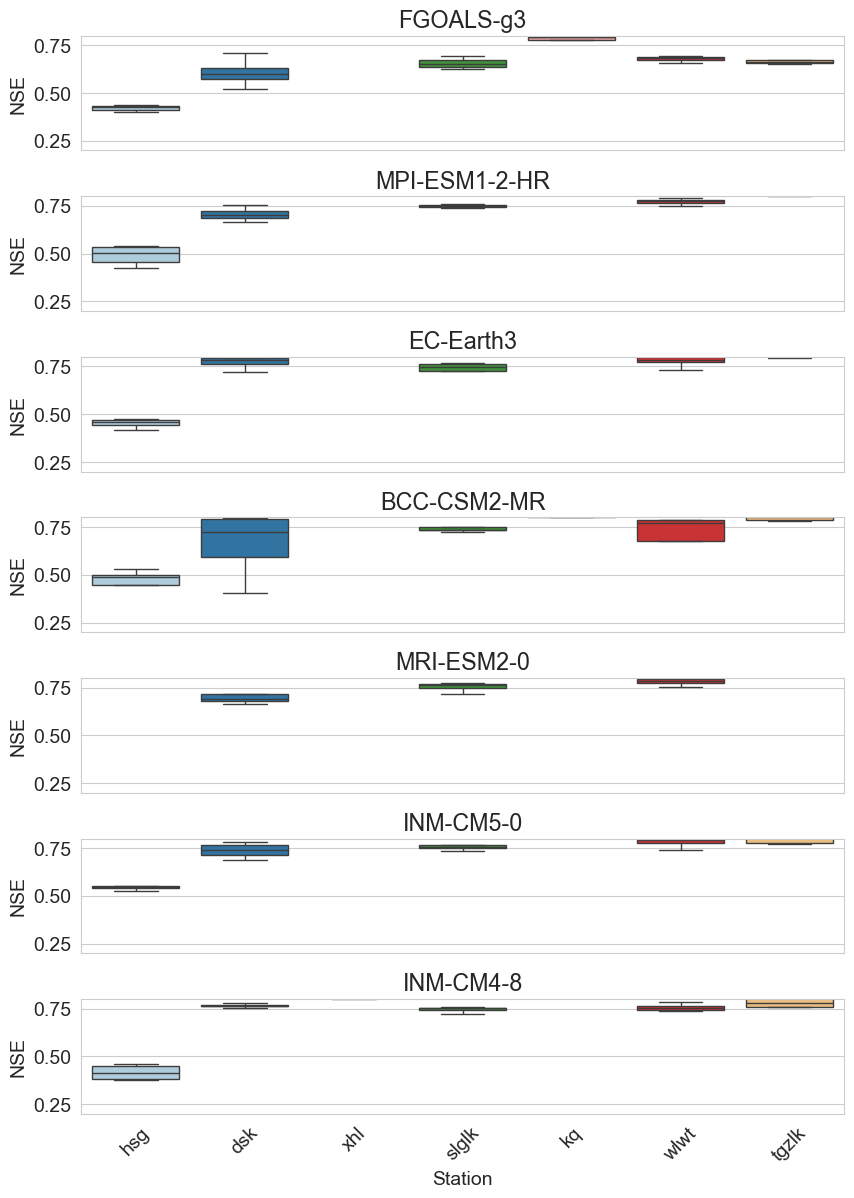

<Figure size 640x480 with 0 Axes>

In [48]:
# Filter unique stations
gcms = evaluation_df['GCM'].unique()

# Set up the figure
fig, axes = plt.subplots(len(gcms), 1, figsize=(9.84, len(stations) * 2))  # 7 rows, 1 column
fig.subplots_adjust(hspace=0.4)  # Adjust spacing between subplots

# Loop through each station and create a plot
for i, gcm in enumerate(gcms):
    gcm_data = evaluation_df[evaluation_df['GCM'] == gcm]
    sns.boxplot(data=gcm_data, x="Station", y="NSE", showfliers=False, palette="Paired", ax=axes[i])
    axes[i].set_title(gcm)
    axes[i].set_ylabel("NSE")
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45)  # Rotate x-axis labels

    # Remove x labels for all but the last plot
    if i < len(gcms) - 1:
        axes[i].set_xlabel("")
        axes[i].set_xticklabels([])

    axes[i].set_ylim(bottom=0.2,top=0.8)

# Add x-axis label only to the last subplot
axes[-1].set_xlabel("Station")

# Show the figure
# Create a figure with a white background
plt.figure(facecolor='white')
plt.tight_layout()
plt.show()

# The follows is for analyzing the exhibition for the adjusted evapotranspiration.

In [49]:
# Step 1: Load data from the text file
columns = ["Station", "GCM", "Scenario", "NSE", "KGE", "Pbias"]

# For monthly runoff
data = []

with open(file_path, "r") as file:
    for line in file:
        if line.startswith("mon Name:"):
            parts = line.split(",")
            name = parts[0].split("_")[1]  # Extract station name (e.g., '1_hsg')
            gcm = parts[0].split("_")[3]   # Extract GCM name (e.g., 'BCC-CSM2-MR')
            scenario = parts[1].split(":")[1].strip()  # Extract scenario
            nse = float(parts[4].split(":")[1].strip())  # Extract NSE
            kge = float(parts[5].split(":")[1].strip())  # Extract KGE
            pbias = float(parts[6].split(":")[1].strip())  # Extract Pbias
            data.append((name, gcm, scenario, nse, kge, pbias))

# Step 2: Convert to DataFrame
columns = ["Station", "GCM", "Scenario", "NSE", "KGE", "Pbias"]
runoff_mon_evaluation_df = pd.DataFrame(data, columns=columns)

# For raw daily runoff
data = []

with open(file_path, "r") as file:
    for line in file:
        if line.startswith("raw Name:"):
            parts = line.split(",")
            name = parts[0].split("_")[1]  # Extract station name (e.g., '1_hsg')
            gcm = parts[0].split("_")[3]   # Extract GCM name (e.g., 'BCC-CSM2-MR')
            scenario = parts[1].split(":")[1].strip()  # Extract scenario
            nse = float(parts[4].split(":")[1].strip())  # Extract NSE
            kge = float(parts[5].split(":")[1].strip())  # Extract KGE
            pbias = float(parts[6].split(":")[1].strip())  # Extract Pbias
            data.append((name, gcm, scenario, nse, kge, pbias))

runoff_raw_evaluation_df = pd.DataFrame(data, columns=columns)


# For daily raw evapotranspiration
data = []

with open(file_path, "r") as file:
    for line in file:
        if line.startswith("Evaporation mon Name:"):
            parts = line.split(",")
            name = parts[0].split("_")[1]  # Extract station name (e.g., '1_hsg')
            gcm = parts[0].split("_")[3]   # Extract GCM name (e.g., 'BCC-CSM2-MR')
            scenario = parts[1].split(":")[1].strip()  # Extract scenario
            nse = float(parts[4].split(":")[1].strip())  # Extract NSE
            kge = float(parts[5].split(":")[1].strip())  # Extract KGE
            pbias = float(parts[6].split(":")[1].strip())  # Extract Pbias
            data.append((name, gcm, scenario, nse, kge, pbias))

ep_mon_evaluation_df = pd.DataFrame(data, columns=columns)

# For monthly evapotranspiration

data = []

with open(file_path, "r") as file:
    for line in file:
        if line.startswith("Evaporation raw Name:"):
            parts = line.split(",")
            name = parts[0].split("_")[1]  # Extract station name (e.g., '1_hsg')
            gcm = parts[0].split("_")[3]   # Extract GCM name (e.g., 'BCC-CSM2-MR')
            scenario = parts[1].split(":")[1].strip()  # Extract scenario
            nse = float(parts[4].split(":")[1].strip())  # Extract NSE
            kge = float(parts[5].split(":")[1].strip())  # Extract KGE
            pbias = float(parts[6].split(":")[1].strip())  # Extract Pbias
            data.append((name, gcm, scenario, nse, kge, pbias))

ep_raw_evaluation_df = pd.DataFrame(data, columns=columns)

In [50]:
evaluation_df

,Station,GCM,Scenario,NSE,KGE,Pbias
0,hsg,FGOALS-g3,SSP126,0.432231,0.552673,-9.304094
1,hsg,FGOALS-g3,SSP245,0.418341,0.572974,-8.609962
2,hsg,FGOALS-g3,SSP370,0.439090,0.589217,-9.523820
3,hsg,FGOALS-g3,SSP585,0.399556,0.525434,-5.580330
4,dsk,FGOALS-g3,SSP126,0.519775,0.763511,-5.991784
...,...,...,...,...,...,...
191,wlwt,INM-CM4-8,SSP585,0.747997,0.869259,-2.444631
192,tgzlk,INM-CM4-8,SSP126,0.802107,0.717284,14.505041
193,tgzlk,INM-CM4-8,SSP245,0.760693,0.706029,16.669263
194,tgzlk,INM-CM4-8,SSP370,0.758892,0.620100,19.931005


In [51]:
runoff_raw_evaluation_df.loc[80:83,['NSE','KGE','Pbias']] - evaluation_df.loc[80:83,['NSE','KGE','Pbias']]

,NSE,KGE,Pbias
80,NaN,NaN,NaN
81,NaN,NaN,NaN
82,NaN,NaN,NaN
83,NaN,NaN,NaN


In [52]:
evaluation_df

,Station,GCM,Scenario,NSE,KGE,Pbias
0,hsg,FGOALS-g3,SSP126,0.432231,0.552673,-9.304094
1,hsg,FGOALS-g3,SSP245,0.418341,0.572974,-8.609962
2,hsg,FGOALS-g3,SSP370,0.439090,0.589217,-9.523820
3,hsg,FGOALS-g3,SSP585,0.399556,0.525434,-5.580330
4,dsk,FGOALS-g3,SSP126,0.519775,0.763511,-5.991784
...,...,...,...,...,...,...
191,wlwt,INM-CM4-8,SSP585,0.747997,0.869259,-2.444631
192,tgzlk,INM-CM4-8,SSP126,0.802107,0.717284,14.505041
193,tgzlk,INM-CM4-8,SSP245,0.760693,0.706029,16.669263
194,tgzlk,INM-CM4-8,SSP370,0.758892,0.620100,19.931005


In [53]:
runoff_raw_evaluation_df[['NSE','KGE','Pbias']].median()

NSE      NaN
KGE      NaN
Pbias    NaN
dtype: object

In [54]:
runoff_mon_evaluation_df[['NSE','KGE','Pbias']].mean()

NSE      NaN
KGE      NaN
Pbias    NaN
dtype: object

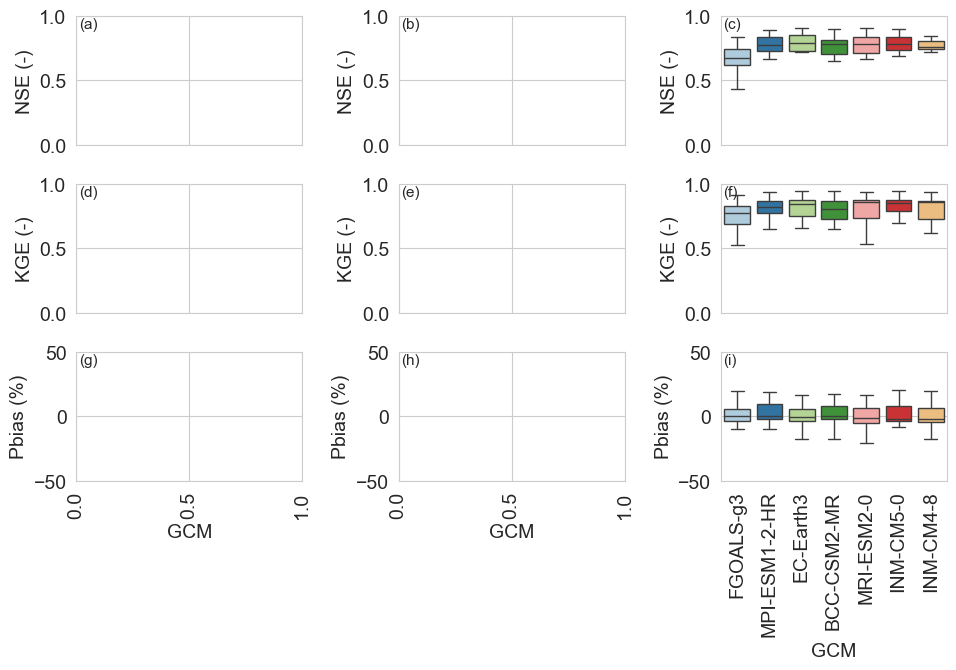

In [55]:
# Step 3: Create a single figure with 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(9.84, 6.93))  # 3 rows, 3 columns
axes = axes.ravel()  # Flatten the axes array for easier indexing

evaluation_df_list = [runoff_mon_evaluation_df,runoff_raw_evaluation_df,evaluation_df]
metric_names = ["NSE", "KGE", "Pbias"]
y_labels = ["NSE (-)", "KGE (-)", "Pbias (%)"]
y_lims = {"NSE": (0, 1), "KGE": (0, 1), "Pbias": (-50, 50)}

for ii, df in enumerate(evaluation_df_list):
    for jj, metric in enumerate(metric_names):
        ax_index = jj * 3 + ii  # Calculate the correct subplot index
        sns.boxplot(
            data=df,
            x="GCM",
            y=metric,
            hue="GCM",
            showfliers=False,
            palette="Paired",  # Use the tab10 palette
            dodge=False,
            ax=axes[ax_index]
        )
        # axes[ax_index].set_title(metric)
        axes[ax_index].set_ylabel(y_labels[jj])
        axes[ax_index].set_ylim(y_lims[metric])  # Apply specific y-limits

        # Remove x-labels for all but the last row
        if jj < 2:  # Rows 0 and 1 (not the last row)
            axes[ax_index].set_xlabel("")
            axes[ax_index].set_xticklabels([])  # Remove tick labels
        else:
            axes[ax_index].set_xlabel("GCM")  # Keep x-labels for the last row

        plt.setp(axes[ax_index].xaxis.get_majorticklabels(), rotation=90)

        label = list(string.ascii_lowercase)[ax_index]
        axes[ax_index].text(
            0.01, 0.99, f'({label})',
            transform=axes[ax_index].transAxes,
            fontsize=11,
            va='top',
            ha='left'
        )

# Adjust layout and show the figure
plt.tight_layout()
plt.show()


In [56]:
runoff_mon_evaluation_df['NSE'].mean()

nan

In [57]:
evaluation_df

,Station,GCM,Scenario,NSE,KGE,Pbias
0,hsg,FGOALS-g3,SSP126,0.432231,0.552673,-9.304094
1,hsg,FGOALS-g3,SSP245,0.418341,0.572974,-8.609962
2,hsg,FGOALS-g3,SSP370,0.439090,0.589217,-9.523820
3,hsg,FGOALS-g3,SSP585,0.399556,0.525434,-5.580330
4,dsk,FGOALS-g3,SSP126,0.519775,0.763511,-5.991784
...,...,...,...,...,...,...
191,wlwt,INM-CM4-8,SSP585,0.747997,0.869259,-2.444631
192,tgzlk,INM-CM4-8,SSP126,0.802107,0.717284,14.505041
193,tgzlk,INM-CM4-8,SSP245,0.760693,0.706029,16.669263
194,tgzlk,INM-CM4-8,SSP370,0.758892,0.620100,19.931005


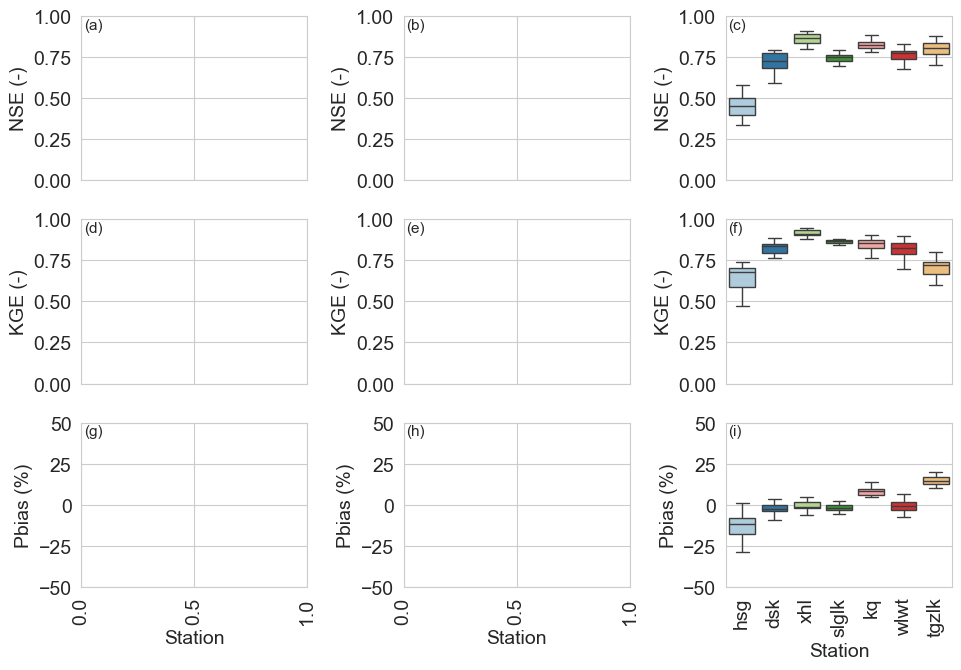

In [58]:
# Step 3: Create a single figure with 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(9.84, 6.93))  # 3 rows, 3 columns
axes = axes.ravel()  # Flatten the axes array for easier indexing

evaluation_df_list = [runoff_mon_evaluation_df,runoff_raw_evaluation_df,evaluation_df]
metric_names = ["NSE", "KGE", "Pbias"]
y_labels = ["NSE (-)", "KGE (-)", "Pbias (%)"]
y_lims = {"NSE": (0, 1), "KGE": (0, 1), "Pbias": (-50, 50)}

for ii, df in enumerate(evaluation_df_list):
    for jj, metric in enumerate(metric_names):
        ax_index = jj * 3 + ii  # Calculate the correct subplot index
        sns.boxplot(
            data=df,
            x="Station",
            y=metric,
            hue="Station",
            showfliers=False,
            palette="Paired",
            dodge=False,
            ax=axes[ax_index]
        )
        # axes[ax_index].set_title(metric)
        axes[ax_index].set_ylabel(y_labels[jj])
        axes[ax_index].set_ylim(y_lims[metric])  # Apply specific y-limits

        # Remove x-labels for all but the last row
        if jj < 2:  # Rows 0 and 1 (not the last row)
            axes[ax_index].set_xlabel("")
            axes[ax_index].set_xticklabels([])  # Remove tick labels
        else:
            axes[ax_index].set_xlabel("Station")  # Keep x-labels for the last row

        plt.setp(axes[ax_index].xaxis.get_majorticklabels(), rotation=90)

        label = list(string.ascii_lowercase)[ax_index]
        axes[ax_index].text(
            0.01, 0.99, f'({label})',
            transform=axes[ax_index].transAxes,
            fontsize=11,
            va='top',
            ha='left'
        )

# Adjust layout and show the figure
plt.tight_layout()
plt.show()


In [59]:
merged_evalution_df = evaluation_df.merge(runoff_raw_evaluation_df,on=['Station','GCM','Scenario'],suffixes=('_fixed','_raw'))

In [60]:
merged_evalution_df.drop(columns='GCM', inplace=True)

In [61]:
merged_evalution_df.groupby(['Station','Scenario']).mean()

,,NSE_fixed,KGE_fixed,Pbias_fixed,NSE_raw,KGE_raw,Pbias_raw
Station,Scenario,,,,,,


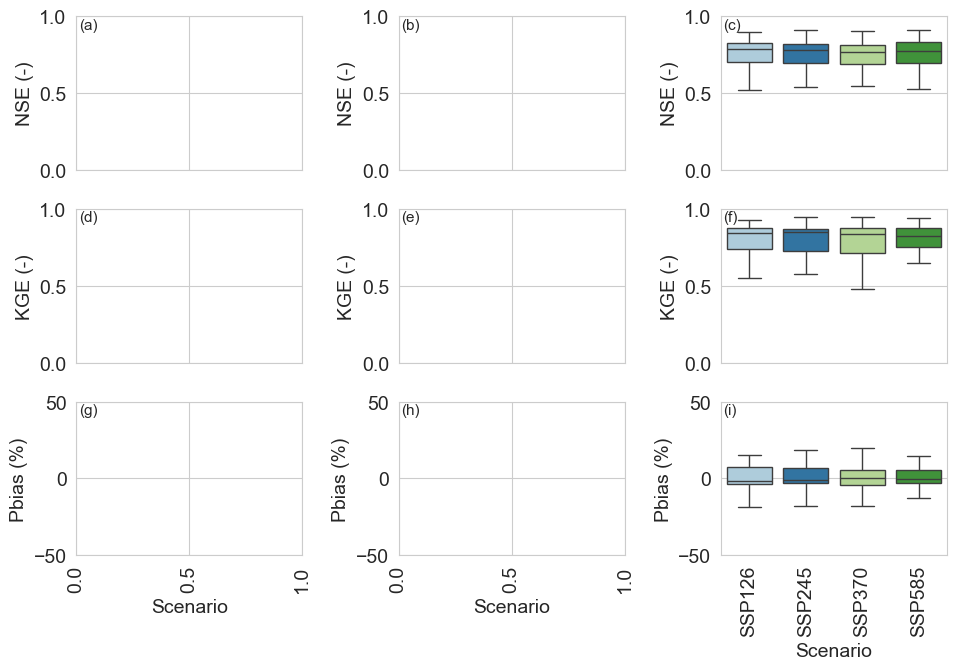

In [62]:
# Step 3: Create a single figure with 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(9.84, 6.93))  # 3 rows, 3 columns
axes = axes.ravel()  # Flatten the axes array for easier indexing

evaluation_df_list = [runoff_mon_evaluation_df, runoff_raw_evaluation_df, evaluation_df]
metric_names = ["NSE", "KGE", "Pbias"]
y_labels = ["NSE (-)", "KGE (-)", "Pbias (%)"]
y_lims = {"NSE": (0, 1), "KGE": (0, 1), "Pbias": (-50, 50)}

for ii, df in enumerate(evaluation_df_list):
    for jj, metric in enumerate(metric_names):
        ax_index = jj * 3 + ii  # Calculate the correct subplot index
        sns.boxplot(
            data=df,
            x="Scenario",
            y=metric,
            hue="Scenario",
            showfliers=False,
            palette="Paired",
            dodge=False,
            ax=axes[ax_index]
        )
        # axes[ax_index].set_title(metric)
        axes[ax_index].set_ylabel(y_labels[jj])
        axes[ax_index].set_ylim(y_lims[metric])  # Apply specific y-limits

        # Remove x-labels for all but the last row
        if jj < 2:  # Rows 0 and 1 (not the last row)
            axes[ax_index].set_xlabel("")
            axes[ax_index].set_xticklabels([])  # Remove tick labels
        else:
            axes[ax_index].set_xlabel("Scenario")  # Keep x-labels for the last row

        plt.setp(axes[ax_index].xaxis.get_majorticklabels(), rotation=90)

        label = list(string.ascii_lowercase)[ax_index]
        axes[ax_index].text(
            0.01, 0.99, f'({label})',
            transform=axes[ax_index].transAxes,
            fontsize=11,
            va='top',
            ha='left'
        )

# Adjust layout and show the figure
plt.tight_layout()
plt.show()


# The follows is for analyzing the exhibition for the adjusted evapotranspiration.

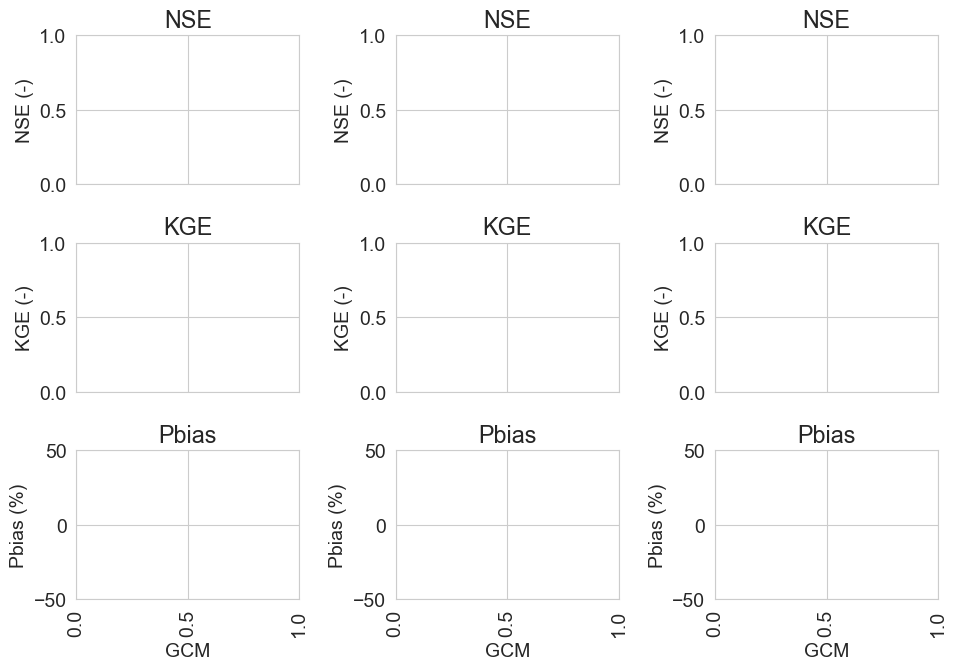

In [63]:
# Step 3: Create a single figure with 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(9.84, 6.93))  # 3 rows, 3 columns
axes = axes.ravel()  # Flatten the axes array for easier indexing

ep_evaluation_df_list = [ep_mon_evaluation_df,ep_raw_evaluation_df, ep_evaluation_df]
metric_names = ["NSE", "KGE", "Pbias"]
y_labels = ["NSE (-)", "KGE (-)", "Pbias (%)"]
y_lims = {"NSE": (-0, 1), "KGE": (-0, 1), "Pbias": (-50, 50)}

for ii, df in enumerate(ep_evaluation_df_list):
    for jj, metric in enumerate(metric_names):
        ax_index = jj * 3 + ii  # Calculate the correct subplot index
        sns.boxplot(
            data=df,
            x="GCM",
            y=metric,
            hue="GCM",
            showfliers=False,
            palette="Paired",
            dodge=False,
            ax=axes[ax_index]
        )
        axes[ax_index].set_title(metric)
        axes[ax_index].set_ylabel(y_labels[jj])
        axes[ax_index].set_ylim(y_lims[metric])  # Apply specific y-limits

        # Remove x-labels for all but the last row
        if jj < 2:  # Rows 0 and 1 (not the last row)
            axes[ax_index].set_xlabel("")
            axes[ax_index].set_xticklabels([])  # Remove tick labels
        else:
            axes[ax_index].set_xlabel("GCM")  # Keep x-labels for the last row

        plt.setp(axes[ax_index].xaxis.get_majorticklabels(), rotation=90)

        # label = list(string.ascii_lowercase)[ax_index]
        # axes[ax_index].text(
        #     0.01, 0.99, f'({label})',
        #     transform=axes[ax_index].transAxes,
        #     fontsize=11,
        #     va='top',
        #     ha='left'
        # )

# Adjust layout and show the figure
plt.tight_layout()
plt.show()


In [64]:
ep_evaluation_df

,Station,GCM,Scenario,NSE,KGE,Pbias


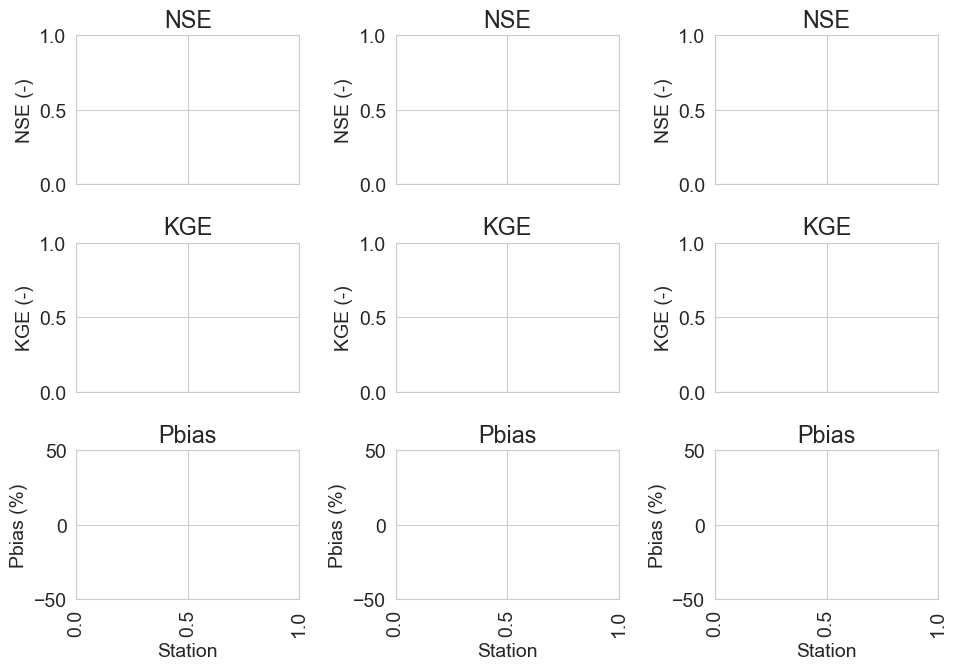

In [65]:
# Step 3: Create a single figure with 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(9.84, 6.93))  # 3 rows, 3 columns
axes = axes.ravel()  # Flatten the axes array for easier indexing

metric_names = ["NSE", "KGE", "Pbias"]
y_labels = ["NSE (-)", "KGE (-)", "Pbias (%)"]
y_lims = {"NSE": (0, 1), "KGE": (0, 1), "Pbias": (-50, 50)}

for ii, df in enumerate(ep_evaluation_df_list):
    for jj, metric in enumerate(metric_names):
        ax_index = jj * 3 + ii  # Calculate the correct subplot index
        sns.boxplot(
            data=df,
            x="Station",
            y=metric,
            hue="Station",
            showfliers=False,
            palette="Paired",
            dodge=False,
            ax=axes[ax_index]
        )
        axes[ax_index].set_title(metric)
        axes[ax_index].set_ylabel(y_labels[jj])
        axes[ax_index].set_ylim(y_lims[metric])  # Apply specific y-limits

        # Remove x-labels for all but the last row
        if jj < 2:  # Rows 0 and 1 (not the last row)
            axes[ax_index].set_xlabel("")
            axes[ax_index].set_xticklabels([])  # Remove tick labels
        else:
            axes[ax_index].set_xlabel("Station")  # Keep x-labels for the last row

        plt.setp(axes[ax_index].xaxis.get_majorticklabels(), rotation=90)

        # label = list(string.ascii_lowercase)[ax_index]
        # axes[ax_index].text(
        #     0.01, 0.99, f'({label})',
        #     transform=axes[ax_index].transAxes,
        #     fontsize=11,
        #     va='top',
        #     ha='left'
        # )

# Adjust layout and show the figure
plt.tight_layout()
plt.show()


In [66]:
ep_raw_evaluation_df

,Station,GCM,Scenario,NSE,KGE,Pbias


In [67]:
ep_evaluation_df

,Station,GCM,Scenario,NSE,KGE,Pbias


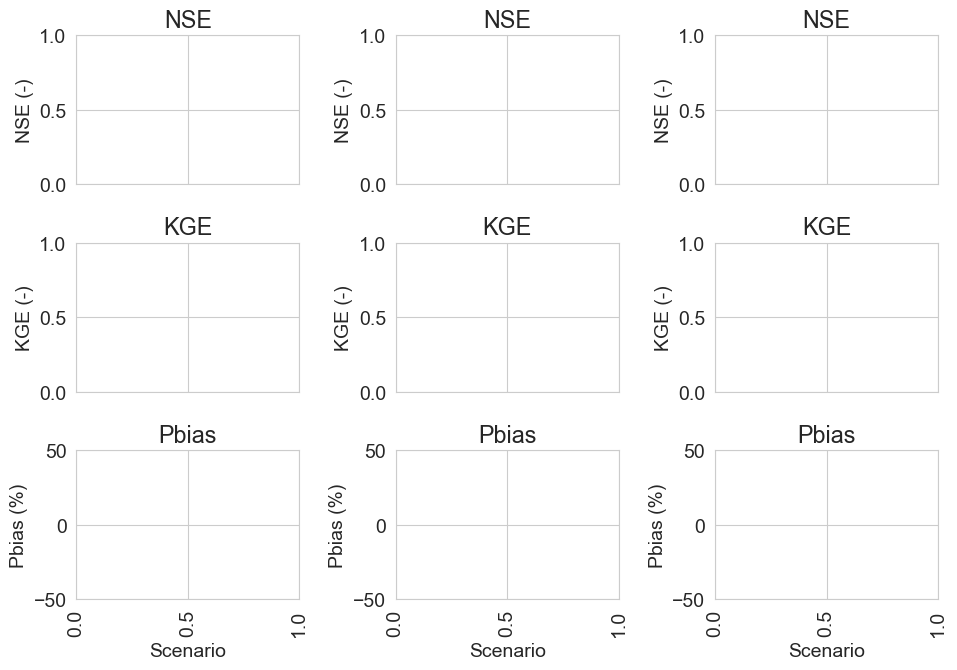

In [68]:
# Step 3: Create a single figure with 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(9.84, 6.93))  # 3 rows, 3 columns
axes = axes.ravel()  # Flatten the axes array for easier indexing

metric_names = ["NSE", "KGE", "Pbias"]
y_labels = ["NSE (-)", "KGE (-)", "Pbias (%)"]
y_lims = {"NSE": (0, 1), "KGE": (0, 1), "Pbias": (-50, 50)}

for ii, df in enumerate(ep_evaluation_df_list):
    for jj, metric in enumerate(metric_names):
        ax_index = jj * 3 + ii  # Calculate the correct subplot index
        sns.boxplot(
            data=df,
            x="Scenario",
            y=metric,
            hue="Scenario",
            showfliers=False,
            palette="Paired",
            dodge=False,
            ax=axes[ax_index]
        )
        axes[ax_index].set_title(metric)
        axes[ax_index].set_ylabel(y_labels[jj])
        axes[ax_index].set_ylim(y_lims[metric])  # Apply specific y-limits

        # Remove x-labels for all but the last row
        if jj < 2:  # Rows 0 and 1 (not the last row)
            axes[ax_index].set_xlabel("")
            axes[ax_index].set_xticklabels([])  # Remove tick labels
        else:
            axes[ax_index].set_xlabel("Scenario")  # Keep x-labels for the last row

        plt.setp(axes[ax_index].xaxis.get_majorticklabels(), rotation=90)

# Adjust layout and show the figure
plt.tight_layout()
plt.show()
